In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки
import matplotlib.pyplot as plt

In [2]:
# Ячейка № 2

# задание функции,
# возвращающей значения
# периодического АС


def Signal(A, Fs, Phi, t):
    # Входные переменные
    # A - амплитуда АС
    # Fs - частота АС
    # Phi - начальная фаза АС
    # t - вектор, содержащий
    # значения моментов времени,
    # в которые вычисляются
    # значения периодического АС

    return A * np.sin(2 * np.pi * Fs * t + Phi)

In [3]:
# Ячейка № 3

# задание функции, возвращающей
# значения координат узлов временной сетки
# и соответствующие значения ДС


def Signal_Discret(A, Fs, Phi, Nperiod, Fdmnless):
    # Входные переменные
    # A - амплитуда АС
    # Fs - частота АС в Гц
    # Phi - начальная фаза АС
    # Nperiod - количество периодов АС,
    #           укладывающихся на временном интервале [0,T0]
    #           (может быть нецелым числом)
    # Fdmnless - безразмерная частота ДС - отношение частоты АС
    #            к частоте дискретизации (1/T1),
    #            Fdmnless <  0.5

    # вычисление размерного значения
    # частоты дискретизации АС в Гц
    Fd = Fs / Fdmnless

    # вычисление периода
    # дискретизации АС в с
    Td = 1 / Fd

    # вычисление длины временного [0, T0],
    # на котором вычисляются значения ДС
    T0 = (1 / Fs) * Nperiod

    # задание координат временной сетки,
    # используемой для вычисления АС
    t = np.arange(0, T0, Td)

    # вычисление координат узлов
    # временной сетки и соответствующих
    # значений АС
    z = Signal(A, Fs, Phi, t)

    return t, z

In [4]:
# Ячейка № 4

# задание функции, возвращающей
# значения интерполяционного
# тригонометрического полинома,
# в соответствие с (7.89), (7.90)
# (четное число узлов временной сетки) и
# (7.92), (7.98) (нечетное число
# узлов временной сетки)
def trigonometric_interp(tk, xk, t):
    # Входные переменные:
    # tk - массив, содержащий абсциссы узлов,
    #      в узлах которой заданы значения ДС
    # xk - массив, содержащий соответствующие
    #      используемой временной сетке значения ДС
    # t – массив, содержащий ординаты узлов,
    #     в которых вычисляются
    #     интерполированные значения АС

    # вычисление значения T0
    T0 = tk[len(tk) - 1] + tk[1]

    # вычисление значения
    # циклической частоты
    # тригонометрического полинома
    Omega0 = 2 * np.pi / T0

    # определение числа отсчетов ДС
    N = len(tk)

    # вычисление значений
    # восстанавливаемого АС
    # для случая четного числа узлов
    # временной сетки
    if N % 2 == 0:
        # вычисление порядка
        # тригонометрического полинома
        N0 = round(N / 2)

        # инициализация массивов,
        # используемых для хранения
        # коэффициентов тригонометрического
        # полинома (7.92)
        a = np.zeros(N0 + 1)
        b = np.zeros(N0 + 1)

        # вычисление значений коэффициентов
        # тригонометрического полинома
        # в соответствие с (1.98)
        a[0] = np.mean(xk)

        Tmp = 0
        for i in range(N):
            Tmp = Tmp + xk[i] * (-1) ** i
        a[N0] = Tmp / N

        for k in range(1, N0):
            a[k] = 2 / N * np.dot(xk, np.cos(k * Omega0 * tk[:]))
            b[k] = 2 / N * np.dot(xk, np.sin(k * Omega0 * tk[:]))

        # инициализация массива,
        # используемого для хранения
        # восстановленных значений АС
        z = np.zeros(len(t))

        # вычисление восстановленных значений АС
        # в соответствие с (7.92)
        for j in range(len(t)):
            s = a[0]
            for k in range(1, N0):
                s = (
                    s
                    + a[k] * np.cos(k * Omega0 * t[j])
                    + b[k] * np.sin(k * Omega0 * t[j])
                )
            z[j] = s + a[N0] * np.cos(N0 * Omega0 * t[j])

    else:
        # вычисление значений
        # восстанавливаемого АС
        # для случая нечетного числа узлов
        # временной сетки

        # вычисление порядка
        # тригонометрического полинома
        N0 = round((N - 1) / 2)

        # инициализация массивов,
        # используемых для хранения
        # коэффициентов тригонометрического
        # полинома (1.89)
        a = np.zeros(N0 + 1)
        b = np.zeros(N0 + 1)

        # вычисление значений коэффициентов
        # тригонометрического полинома
        # в соответствие с (7.90)
        a[0] = np.mean(xk)

        for k in range(1, N0 + 1):
            a[k] = 2 / N * np.dot(xk, np.cos(k * Omega0 * tk[:]))
            b[k] = 2 / N * np.dot(xk, np.sin(k * Omega0 * tk[:]))

        # инициализация массива,
        # используемого для хранения
        # восстановленных значений АС
        z = np.zeros(len(t))

        # вычисление восстановленных значений АС
        # в соответствие с (7.89)
        for j in range(len(t)):
            s = a[0]
            for k in range(1, N0 + 1):
                s = (
                    s
                    + a[k] * np.cos(k * Omega0 * t[j])
                    + b[k] * np.sin(k * Omega0 * t[j])
                )
            z[j] = s
    return z

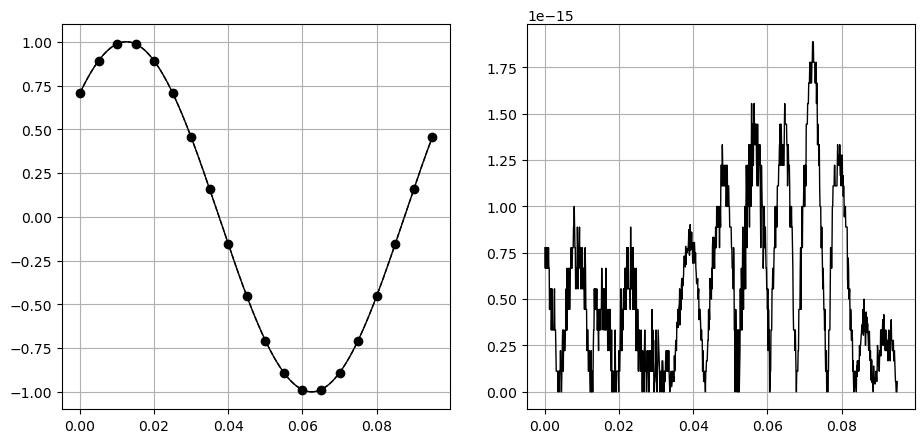

In [ ]:
# Ячейка № 5

# восстановление АС на
# с помощью тригонометрического
# полинома

# задание амплитуды АС
A = 1

# задание частоты АС в Гц
Fs = 10

# задание начальной фазы АС
Phi = np.pi / 4

# задание числа периодов АС,
# укладывающихся на интервале [0,T0]
Nperiod = 1.0

# вычисление значения T0
T0 = Nperiod / Fs

# задание значения
# безразмерной частоты ДС
# (безразмерная частота ДС -
# отношение частоты сигнала к
# к частоте дискретизации)
Fdmnless = 0.05

# задание числа узлов временной сетки,
# использованной для вычисления значений
# восстановленного АС
Np = 10**3

# вычисление значений ДС
t, z = Signal_Discret(A, Fs, Phi, Nperiod, Fdmnless)

# вычисление координат временной сетки,
# использованной для вычисления значений
# восстановленного АС
Time = np.linspace(0, t[len(t) - 1], Np, endpoint=True)

# вычисление значений АС
Za = Signal(A, Fs, Phi, Time)

# вычисление значений восстановленного АС
Z_interp = trigonometric_interp(t, z, Time)

# визуализация АС, ДС, восстановленного АС и
# разности значений АС и восстановленного АС
fig = plt.figure(figsize=(11, 5))

ax = fig.add_subplot(121)

plt.plot(Time, Za, "--k", lw=1)
plt.plot(Time, Z_interp, "-k", lw=1)
plt.plot(t, z, "o", color="k", lw=1)
plt.grid(True)

ax = fig.add_subplot(122)
plt.plot(Time, np.abs(Z_interp - Za), "-k", lw=1)
plt.grid(True)

plt.show()